# 🧠 Prediciendo el VIX con una LSTM — versión guiada, paso a paso

**Clase 10 — Introducción al Deep Learning**
**Dataset:** `econotrend_vix_sim.csv` · **Ventana (lookback):** 10 días · **Meta:** predecir el VIX de mañana

---

### Cómo leer este notebook

Este notebook está pensado para **explicarse en clase**, no solo para correrse. Cada bloque de código
va precedido de una celda de markdown que responde tres preguntas:

1. **¿Qué vamos a hacer?**
2. **¿Por qué lo hacemos así y no de otra forma?**
3. **¿Qué deberíamos ver / entender en el resultado?**

Si en algún punto se pierden, vuelvan al **mapa mental** de abajo — todo el notebook es una respuesta a esa
única pregunta.

> ## La pregunta que persigue todo el notebook
> **"Si te muestro los últimos 10 días del VIX, ¿podés adivinar el de mañana?"**
>
> Todo lo que sigue — normalizar, armar ventanas, entrenar una LSTM, compararla con modelos simples —
> es responder esa pregunta de forma rigurosa.


## 🗺️ Mapa mental del notebook

```
1. ¿Qué es el VIX y por qué una LSTM?      → intuición, sin código
2. Setup                                    → herramientas que vamos a usar
3. EDA                                      → mirar los datos antes de tocarlos
4. Preparar los datos                       → normalizar + ventanas deslizantes + split temporal
5. El modelo LSTM                           → arquitectura, explicada con analogías
6. Entrenamiento                            → cómo "aprende" la red (gradiente descendente)
7. Validación cruzada temporal              → ¿el modelo es consistente en el tiempo?
8. Evaluación                               → LSTM vs. modelos base (¿vale la pena la complejidad?)
9. Conclusiones                             → qué aprendimos del VIX y de la LSTM
10. Glosario exprés                         → términos clave para repasar
```


## 1. ¿Qué es el VIX y por qué una LSTM?

### El VIX, en una frase
El **VIX** ("índice del miedo") mide **cuánta volatilidad espera el mercado** en el S&P 500 para los
próximos 30 días. No mide si el mercado sube o baja — mide **cuánto se espera que se mueva**.

- VIX bajo (10-20) → mercado tranquilo, calma.
- VIX alto (>30) → mercado nervioso, incertidumbre, pánico.

Es una **serie temporal**: cada valor depende (al menos un poco) de los valores anteriores. Si eso es
cierto, entonces **hay señal para predecir**, y ahí es donde entra el Deep Learning.

### ¿Por qué no alcanza con un modelo clásico (ARIMA, regresión)?
Los modelos clásicos de series temporales suelen asumir que la relación entre pasado y futuro es
**lineal** y que la serie es **estacionaria** (su comportamiento estadístico no cambia con el tiempo).
Esos supuestos no siempre se cumplen en mercados financieros.

Una **LSTM (Long Short-Term Memory)** es un tipo de red neuronal recurrente diseñada para leer
**secuencias** (como leer un texto palabra por palabra, o una serie de tiempo día por día) y mantener
una **memoria interna** que va actualizando a medida que "lee". No necesita que le digamos de antemano
qué forma tiene la relación entre pasado y futuro — la aprende de los datos.

### La analogía que conviene tener en la cabeza
Pensá en la LSTM como **una persona que lee un diario día por día** y va llevando un resumen mental de lo
importante ("el mercado viene nervioso hace una semana", "esto se calmó ayer"). Cada día, esa persona
decide tres cosas:

| Decisión | Nombre técnico | En criollo |
|---|---|---|
| ¿Qué del resumen mental ya no importa y puedo olvidar? | **Forget gate** | "esto ya quedó viejo, lo tiro" |
| ¿Qué de lo que leí hoy es importante y merece agregarse al resumen? | **Input gate** | "esto es nuevo e importante, lo anoto" |
| Con el resumen actualizado, ¿qué le cuento a la siguiente persona (o qué uso para predecir)? | **Output gate** | "esto es lo que importa contar ahora" |

Estas tres "puertas" (*gates*) son la razón por la que la LSTM puede recordar información relevante
durante muchos pasos de tiempo sin "olvidarla" — el problema que sufrían las RNN clásicas, conocido como
**gradiente desvaneciente** (el error que usamos para aprender se hace tan chico al viajar hacia atrás en
el tiempo que la red deja de aprender de lo que pasó hace muchos días).

**No hace falta memorizar las fórmulas de las puertas** para entender ni explicar esta clase. Lo que
importa es la idea: *la LSTM decide activamente qué recordar y qué olvidar, en vez de arrastrar todo el
historial a ciegas.*


## 2. Setup — las herramientas que vamos a usar

Antes de tocar datos, importamos las librerías. Para que quede claro **el rol de cada una**:

| Librería | Para qué la usamos acá |
|---|---|
| `numpy` / `pandas` | manipular números y series de tiempo |
| `matplotlib` | graficar |
| `torch` (PyTorch) | construir y entrenar la red neuronal (LSTM) |
| `sklearn` | normalizar los datos, y como fuente de modelos "base" (regresión lineal) y métricas |

Dos líneas merecen explicación aparte:

- `torch.manual_seed(42)` y `np.random.seed(42)`: los pesos iniciales de la red y algunos procesos de
  entrenamiento tienen un componente aleatorio. Fijar una **semilla** hace que, si corren este notebook
  de nuevo, obtengan (casi) los mismos resultados. Es clave para poder comparar experimentos.
- `DEVICE`: PyTorch puede entrenar en la placa de video (`cuda`) si hay una disponible, o en el
  procesador (`cpu`) si no. Con un dataset chico como este, `cpu` es perfectamente suficiente.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Semillas fijas -> resultados reproducibles
torch.manual_seed(42)
np.random.seed(42)

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Setup OK | Device: {DEVICE}')

Setup OK | Device: cpu


**Cómo leer el output:** si ven `cpu`, es normal y esperable en la mayoría de las notebooks —
entrenar 50 épocas sobre ~1.300 filas tarda segundos. Si tuvieran una GPU (`cuda`), el entrenamiento
sería más rápido, pero con este volumen de datos la diferencia no se nota.


## 3. EDA — mirar los datos antes de modelar

### ¿Por qué EDA antes de cualquier modelo?
Nunca se debe entrenar un modelo "a ciegas". Antes de programar una sola línea de red neuronal, tenemos
que poder responder tres preguntas sobre la serie:

1. **¿Hay tendencia?** (¿sube o baja en el largo plazo?)
2. **¿Hay estacionalidad?** (¿se repiten patrones cada tanto tiempo?)
3. **¿Hay autocorrelación?** (¿el valor de hoy se parece al de ayer, o al de hace una semana?)

La respuesta a la pregunta 3 es la más importante para nosotros: **si no hay autocorrelación, no hay
nada que un modelo secuencial como la LSTM pueda aprovechar** (la serie sería puro ruido, un
*random walk*, y estaríamos perdiendo el tiempo).


In [2]:
# Cargar y limpiar
df = pd.read_csv('../data/econotrend_vix_sim.csv', parse_dates=['date'], index_col='date')
df = df.dropna()  # por si hubiera nulos

print(f'Dataset: {len(df)} registros | {df.index.min().date()} -> {df.index.max().date()}')
print(f'VIX -- media: {df.vix.mean():.2f} | std: {df.vix.std():.2f} | min: {df.vix.min():.2f} | max: {df.vix.max():.2f}')

Dataset: 1305 registros | 2020-10-07 -> 2025-10-07
VIX -- media: 21.54 | std: 2.34 | min: 15.20 | max: 28.82


**Cómo leer el output:** anoten la media y el rango — los vamos a necesitar más adelante para
juzgar si el error del modelo es grande o chico. Un `MAE` (error promedio) de 1 punto de VIX no significa
lo mismo si la media es 21 que si fuera 100.

Ahora sí, cuatro gráficos para responder las tres preguntas de arriba:


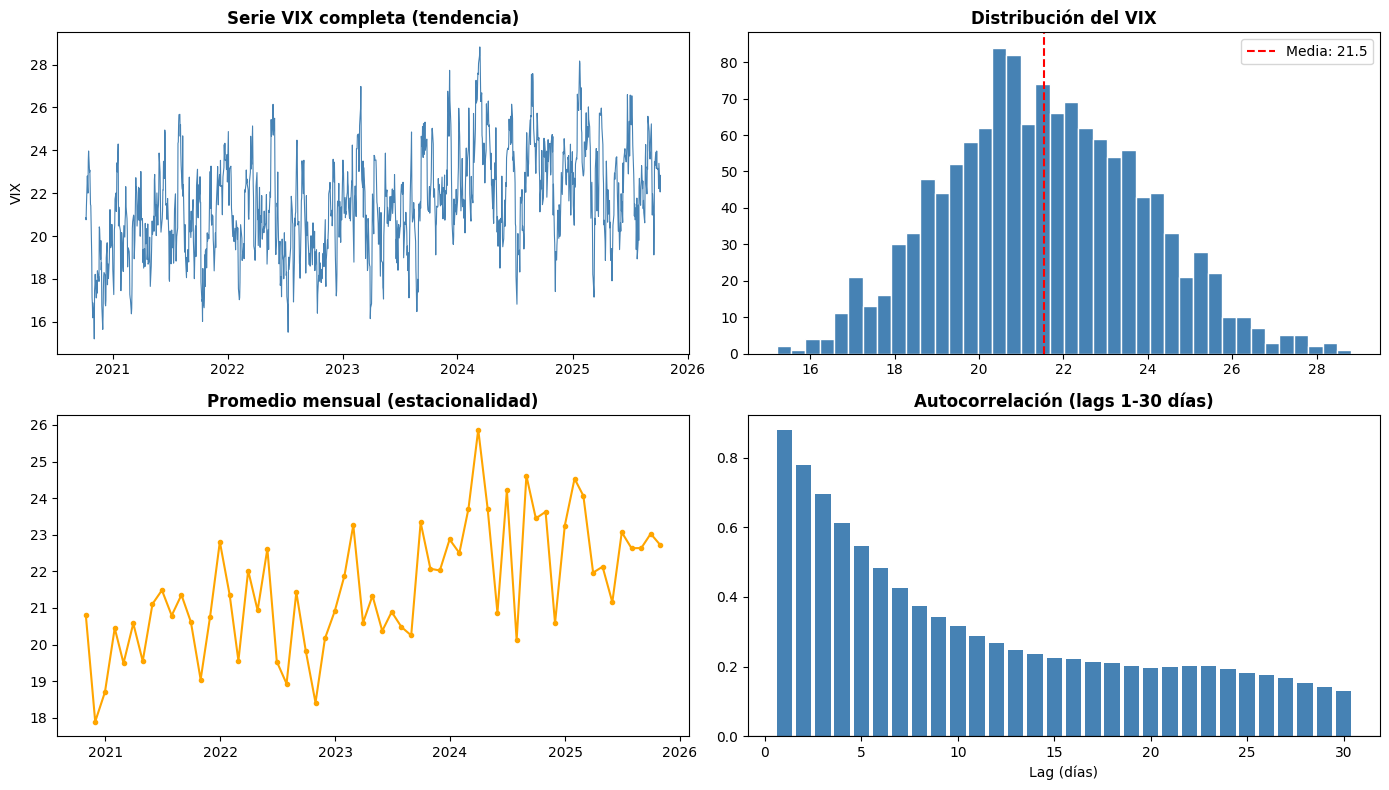

In [3]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

# (1) Serie completa -> ¿hay tendencia?
axes[0, 0].plot(df.index, df.vix, color='steelblue', linewidth=0.8)
axes[0, 0].set_title('Serie VIX completa (tendencia)', fontweight='bold')
axes[0, 0].set_ylabel('VIX')

# (2) Distribución -> ¿qué tan disperso es el VIX?
axes[0, 1].hist(df.vix, bins=40, color='steelblue', edgecolor='white')
axes[0, 1].set_title('Distribución del VIX', fontweight='bold')
axes[0, 1].axvline(df.vix.mean(), color='red', linestyle='--', label=f'Media: {df.vix.mean():.1f}')
axes[0, 1].legend()

# (3) Promedio mensual -> ¿hay estacionalidad?
monthly_mean = df.vix.resample('ME').mean()
axes[1, 0].plot(monthly_mean.index, monthly_mean.values, color='orange', marker='o', markersize=3)
axes[1, 0].set_title('Promedio mensual (estacionalidad)', fontweight='bold')

# (4) Autocorrelación -> ¿el pasado predice el futuro?
lags = range(1, 31)
autocorrs = [df.vix.autocorr(lag=l) for l in lags]
axes[1, 1].bar(lags, autocorrs, color='steelblue')
axes[1, 1].axhline(0, color='black', linewidth=0.8)
axes[1, 1].set_title('Autocorrelación (lags 1-30 días)', fontweight='bold')
axes[1, 1].set_xlabel('Lag (días)')

plt.tight_layout()
plt.show()

**Cómo leer estos 4 gráficos (de a uno):**

- **Arriba-izquierda (serie completa):** noten el rango tan acotado (más adelante van a ver que es
  15-29, mucho más chico que el VIX real, que llegó a >80 en la pandemia). Esto nos dice que estamos
  frente a un dataset **simulado y suavizado**, sin crisis extremas.
- **Arriba-derecha (histograma):** una distribución razonablemente centrada alrededor de la media, sin
  colas larguísimas. Otra pista de que es una serie "domesticada".
- **Abajo-izquierda (promedio mensual):** si ven oscilaciones suaves, hay algo de estacionalidad, aunque
  no es el foco de este análisis.
- **Abajo-derecha (autocorrelación) — el gráfico más importante:** si las primeras barras (lag 1 a 5)
  son altas y positivas, significa que **el VIX de ayer se parece mucho al de hoy** → hay memoria en la
  serie → hay señal predecible → **no es un random walk puro**. Esto justifica todo lo que viene después.


## 4. Preparación de datos

Esta es, en la práctica, **la parte más importante de todo el notebook**. Una LSTM mal alimentada no
aprende nada, sin importar cuán sofisticada sea la arquitectura. Vamos a hacer tres cosas, en este orden,
y cada una tiene una razón muy concreta para existir:

1. **Normalizar** (escalar los valores a un rango chico y fijo)
2. **Armar "ventanas deslizantes"** (convertir la serie en pares "10 días pasados → 1 día futuro")
3. **Dividir en train/test respetando el tiempo** (nunca mezclar pasado y futuro)

### 4.1 — ¿Por qué normalizar?
Las redes neuronales entrenan mejor cuando los números de entrada están en un rango chico y estable
(por ejemplo, entre 0 y 1). Si dejáramos el VIX en su escala original (15 a 29), no rompería nada
matemáticamente, pero el entrenamiento sería más lento e inestable. Usamos `MinMaxScaler`, que aplica
esta transformación:

$$x_{escalado} = \frac{x - x_{min}}{x_{max} - x_{min}}$$

> ⚠️ **La regla de oro que NO se puede romper:** el `scaler` se ajusta (`fit`) **solo con los datos de
> train**, y después se aplica (`transform`) al test **sin volver a ajustarlo**. Si ajustáramos el
> scaler con todo el dataset, el `min` y el `max` que "aprende" incluirían información del futuro
> (test) — eso se llama **data leakage** (fuga de información) y hace que el modelo parezca mejor de lo
> que realmente es.

### 4.2 — ¿Qué es una "ventana deslizante" (sliding window)?
La LSTM no puede recibir "toda la serie de una vez y adivinar el próximo valor" — necesita ejemplos
concretos de entrada/salida, como cualquier modelo supervisado. Convertimos la serie en pares
`(X, y)` así:

```
día:        1    2    3    4    5    6    7    8    9   10   11   12  ...
VIX:       20.1 20.3 19.8 21.0 20.5 19.9 20.7 21.2 20.9 21.5 22.0 21.8 ...

Ejemplo 1 -> X = [día 1 a día 10]   ->  y = día 11 (22.0)
Ejemplo 2 -> X = [día 2 a día 11]   ->  y = día 12 (21.8)
...la ventana se "desliza" un día a la vez...
```

Con `lookback = 10`, cada `X` tiene 10 valores (los últimos 10 días) y cada `y` es un solo número
(el valor del día siguiente). Es exactamente igual a como un humano predeciría: "mirando la última
semana y media, ¿qué esperás para mañana?".

### 4.3 — ¿Por qué el split no puede ser aleatorio?
En un dataset "normal" (por ejemplo, precios de casas), separaríamos train/test al azar. **Acá no**:
si mezcláramos los días, el modelo podría terminar entrenando con datos de una semana y siendo
evaluado con datos de una semana *anterior* — es decir, **el modelo "vería" el futuro durante el
entrenamino**, lo cual es trampa y no reflejaría cómo se usaría en la vida real (donde solo tenemos el
pasado para predecir el futuro). Por eso: **train = primer 80% cronológico, test = último 20%
cronológico**, sin barajar.


In [4]:
LOOKBACK = 10   # cuántos días miramos hacia atrás para predecir el siguiente
SPLIT = 0.8     # 80% train / 20% test, respetando el orden temporal

# --- Paso 1: dividir ANTES de normalizar, respetando el tiempo ---
n = len(df)
split_idx = int(n * SPLIT)
train_raw = df.vix.values[:split_idx].reshape(-1, 1)
test_raw  = df.vix.values[split_idx:].reshape(-1, 1)

# --- Paso 2: normalizar (fit SOLO en train, transform en ambos) ---
scaler = MinMaxScaler()
train_scaled = scaler.fit_transform(train_raw)
test_scaled  = scaler.transform(test_raw)

print(f'Train: {len(train_scaled)} dias | Test: {len(test_scaled)} dias')

Train: 1044 dias | Test: 261 dias


In [5]:
def make_sequences(data, lookback):
    """Convierte una serie 1D en pares (X, y):
    X = ventana de `lookback` dias, y = el dia siguiente."""
    X, y = [], []
    for i in range(lookback, len(data)):
        X.append(data[i - lookback:i, 0])  # los `lookback` dias anteriores
        y.append(data[i, 0])               # el dia que queremos predecir
    return np.array(X), np.array(y)

# --- Paso 3: armar las ventanas para train y test por separado ---
X_train, y_train = make_sequences(train_scaled, LOOKBACK)
X_test,  y_test  = make_sequences(test_scaled,  LOOKBACK)

print(f'X_train shape: {X_train.shape}  -> (cantidad de ejemplos, dias por ventana)')
print(f'X_test  shape: {X_test.shape}')

X_train shape: (1034, 10)  -> (cantidad de ejemplos, dias por ventana)
X_test  shape: (251, 10)


**Cómo leer el output:** si el dataset tenía, por ejemplo, 1.044 filas de train, ahora tenemos
1.034 *ejemplos* (1.044 − 10). Perdemos exactamente `lookback` ejemplos porque las primeras 10 filas no
tienen 10 días previos completos para armar una ventana. Es un costo esperado y normal.


### 4.4 — De arrays de NumPy a tensores de PyTorch

PyTorch no trabaja con arrays de NumPy directamente — trabaja con **tensores**, su propia estructura de
datos (muy similar a un array de NumPy, pero optimizada para calcular gradientes y correr en GPU).

Un detalle importante de forma (*shape*): la capa LSTM de PyTorch espera los datos con 3 dimensiones,
en el orden `(batch, seq_len, features)`:

- **batch**: cuántos ejemplos procesamos juntos
- **seq_len**: cuántos pasos de tiempo tiene cada ejemplo (acá, 10 — nuestro `lookback`)
- **features**: cuántas variables medimos en cada paso de tiempo (acá, 1 — solo el VIX)

Nuestros arrays hoy tienen shape `(ejemplos, 10)` — les falta la dimensión de `features`. Por eso usamos
`.unsqueeze(-1)`, que agrega una dimensión extra al final: `(ejemplos, 10)` → `(ejemplos, 10, 1)`.


In [6]:
# Convertir a tensores de PyTorch y agregar la dimension de "features"
X_train_t = torch.FloatTensor(X_train).unsqueeze(-1)
y_train_t = torch.FloatTensor(y_train).unsqueeze(-1)
X_test_t  = torch.FloatTensor(X_test).unsqueeze(-1)
y_test_t  = torch.FloatTensor(y_test).unsqueeze(-1)

print(f'X_train_t shape: {tuple(X_train_t.shape)}  -> (batch, seq_len=10, features=1)')

# DataLoader: entrega los datos en "lotes" (batches) durante el entrenamiento,
# en vez de pasar los 1000+ ejemplos de una sola vez a la red.
train_loader = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=32, shuffle=False)

X_train_t shape: (1034, 10, 1)  -> (batch, seq_len=10, features=1)


**¿Por qué entrenar por batches y no con todos los datos juntos?** Actualizar los pesos de la red
mirando 32 ejemplos a la vez (en vez de 1.000+ de una sola vez) hace que el entrenamiento sea más rápido,
consuma menos memoria y, en la práctica, ayude a que el modelo generalice mejor. `shuffle=False` porque,
aunque mezclar el *orden de los batches* no rompe la regla temporal (cada ejemplo ya es una ventana
válida), mantenemos el orden por prolijidad y reproducibilidad.


## 5. El modelo LSTM

### La arquitectura, en dos pasos
1. **Capa LSTM**: lee la secuencia de 10 días, paso a paso, y va actualizando su "memoria" interna
   (como la persona leyendo el diario de la Sección 1).
2. **Capa densa (`Linear`)**: toma el resumen final de la LSTM (el estado del último día) y lo convierte
   en **un solo número**: la predicción del VIX de mañana.

### ¿Por qué usamos solo la salida del último paso de tiempo?
La LSTM produce una salida en **cada** uno de los 10 pasos (una por cada día de la ventana), pero a
nosotros solo nos interesa predecir *después* del décimo día. La salida del último paso
(`lstm_out[:, -1, :]`) es la que ya acumuló toda la información de los 10 días anteriores — es el
"resumen final" de la persona que terminó de leer el diario.

### Los hiperparámetros de esta red

| Parámetro | Valor | Qué significa |
|---|---|---|
| `hidden_size` | 64 | tamaño de la "memoria interna" (más grande = más capacidad, pero más riesgo de sobreajuste) |
| `num_layers` | 2 | apilamos 2 capas LSTM, una encima de la otra, para captar patrones más complejos |
| `dropout` | 0.2 | durante el entrenamiento, apaga aleatoriamente el 20% de las neuronas en cada paso — evita que la red dependa demasiado de una sola "ruta" y ayuda a generalizar |


In [7]:
class VIX_LSTM(nn.Module):
    def __init__(self, input_size=1, hidden_size=64, num_layers=1, dropout=0.2):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,        # nuestros tensores vienen como (batch, seq, features)
            dropout=dropout if num_layers > 1 else 0
        )
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_size, 1)  # capa densa: memoria (64 numeros) -> 1 prediccion

    def forward(self, x):
        lstm_out, _ = self.lstm(x)        # lstm_out: (batch, seq=10, hidden=64)
        last_out = lstm_out[:, -1, :]     # nos quedamos solo con el ultimo paso de tiempo
        out = self.dropout(last_out)
        return self.fc(out)               # (batch, 1) -> la prediccion final

model = VIX_LSTM(hidden_size=64, num_layers=2, dropout=0.2).to(DEVICE)
print(model)

total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'\nParametros entrenables: {total_params:,}')

VIX_LSTM(
  (lstm): LSTM(1, 64, num_layers=2, batch_first=True, dropout=0.2)
  (dropout): Dropout(p=0.2, inplace=False)
  (fc): Linear(in_features=64, out_features=1, bias=True)
)

Parametros entrenables: 50,497


**Cómo leer el output:** van a ver algo como **~50.000 parámetros entrenables**. Es mucho para un
dataset de ~1.300 filas (más parámetros que ejemplos de entrenamiento) — algo para tener en cuenta:
cuantos más parámetros tiene un modelo en relación a la cantidad de datos, más riesgo de que
**memorice** en vez de **generalizar** (overfitting). Lo vamos a volver a mencionar en las conclusiones.


## 6. Entrenamiento — cómo "aprende" la red

### La idea central: descenso por gradiente
Recuerden la analogía de la presentación teórica: entrenar una red es como **bajar una colina con los
ojos vendados**. En cada paso:

1. La red hace una predicción (mira el terreno bajo sus pies).
2. Medimos qué tan mal predijo (**la función de pérdida** — acá, `MSELoss`, el error cuadrático medio).
3. Calculamos hacia qué dirección hay que mover cada peso de la red para reducir ese error
   (**backpropagation** — PyTorch lo hace automáticamente con `loss.backward()`).
4. Damos un pasito en esa dirección (**el optimizador**, acá `Adam`, ajusta los pesos).
5. Repetimos, una y otra vez, hasta que el error deja de bajar de forma significativa.

Cada vuelta completa sobre **todos** los datos de entrenamiento se llama una **época** (*epoch*).
Entrenamos durante 50 épocas.

### Las 5 líneas que son el corazón de cualquier entrenamiento en PyTorch
Dentro del loop, van a ver siempre esta misma secuencia — vale la pena memorizarla, porque se repite en
prácticamente cualquier modelo de PyTorch que entrenen en el futuro:

```python
optimizer.zero_grad()   # 1. "borrar el pizarrón": limpiar gradientes de la vuelta anterior
pred = model(X_batch)   # 2. forward pass: la red predice
loss = criterion(pred, y_batch)  # 3. medir el error
loss.backward()         # 4. backward pass: calcular gradientes (¿hacia dónde mover los pesos?)
optimizer.step()        # 5. actualizar los pesos en esa dirección
```

¿Por qué hay que "limpiar" los gradientes en el paso 1? Porque PyTorch **acumula** gradientes por
default (los suma en vez de reemplazarlos) — si no los reiniciamos, mezclaríamos la información de
distintos batches y el entrenamiento se rompería.


In [8]:
EPOCHS = 50
LR = 0.001  # learning rate: el "tamaño del paso" al bajar la colina

criterion = nn.MSELoss()                              # que tan lejos esta la prediccion del valor real
optimizer = torch.optim.Adam(model.parameters(), lr=LR)  # como ajustamos los pesos

train_losses = []

for epoch in range(EPOCHS):
    model.train()
    epoch_loss = 0
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(DEVICE), y_batch.to(DEVICE)

        optimizer.zero_grad()          # 1. limpiar gradientes
        pred = model(X_batch)          # 2. forward pass
        loss = criterion(pred, y_batch)  # 3. medir error
        loss.backward()                # 4. backward pass (backpropagation)
        optimizer.step()               # 5. actualizar pesos

        epoch_loss += loss.item()

    avg_loss = epoch_loss / len(train_loader)
    train_losses.append(avg_loss)

    if (epoch + 1) % 10 == 0:
        print(f'Epoca [{epoch+1:3d}/{EPOCHS}] | Loss: {avg_loss:.6f}')

Epoca [ 10/50] | Loss: 0.019080


Epoca [ 20/50] | Loss: 0.011283


Epoca [ 30/50] | Loss: 0.009394


Epoca [ 40/50] | Loss: 0.008683


Epoca [ 50/50] | Loss: 0.008406


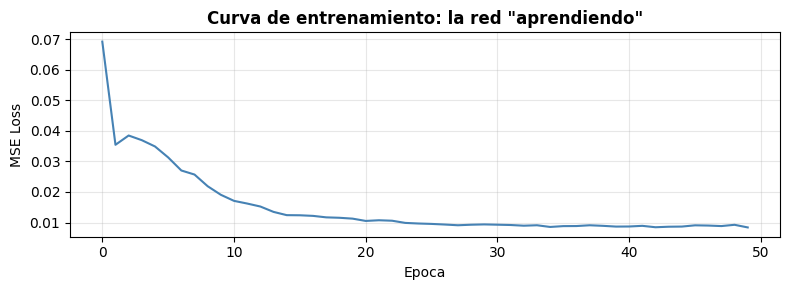

In [9]:
plt.figure(figsize=(8, 3))
plt.plot(train_losses, color='steelblue')
plt.xlabel('Epoca')
plt.ylabel('MSE Loss')
plt.title('Curva de entrenamiento: la red "aprendiendo"', fontweight='bold')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

**Cómo leer la curva de entrenamiento (algo que van a hacer TODO el tiempo en Deep Learning):**

- **Debe bajar y estabilizarse.** Si baja rápido al principio y luego se aplana, es la señal esperada:
  el modelo convergió (encontró un buen conjunto de pesos y ya no mejora mucho más).
- **Si sigue bajando fuerte al final**, faltarían más épocas.
- **Si "rebota" o sube**, el `learning rate` suele ser demasiado alto (los pasos son muy grandes y la
  red "se pasa" del mínimo).
- Acá deberían ver que la pérdida cae bastante en las primeras épocas y luego la mejora se vuelve
  marginal — es la forma típica y saludable de una curva de entrenamiento.


## 7. Validación cruzada temporal (TimeSeriesSplit)

### ¿Por qué no usamos K-Fold "normal"?
El K-Fold clásico mezcla los datos al azar en distintos grupos (*folds*). En series de tiempo eso
**vuelve a romper la regla de oro**: entrenaríamos con datos "del futuro" para predecir "el pasado".

`TimeSeriesSplit` resuelve esto generando varios cortes (folds) donde **el conjunto de validación
siempre es posterior, en el tiempo, al de entrenamiento** — como hacer el split de la Sección 4, pero
varias veces, cada vez con un poco más de historia.

### ¿Para qué sirve, además de "hacerlo bien"?
Nos da una idea de **qué tan estable es el modelo** a través de distintos períodos, en vez de confiar en
un único split. Si el error varía mucho entre folds, es señal de que el comportamiento de la serie
cambió en algún momento (un cambio de régimen).

> **Nota práctica:** para que esta validación no tarde una eternidad, cada fold entrena un modelo nuevo
> con menos épocas (20 en vez de 50). Por eso los errores de esta sección van a ser *un poco peores* que
> los del modelo final — no es un problema, es prevé.


In [10]:
from sklearn.model_selection import TimeSeriesSplit

tscv = TimeSeriesSplit(n_splits=5)
scaled_full = scaler.transform(df.vix.values.reshape(-1, 1))
X_full, y_full = make_sequences(scaled_full, LOOKBACK)

cv_maes = []
print('TimeSeriesSplit -- MAE por fold (espacio normalizado 0-1):')
for fold, (tr_idx, val_idx) in enumerate(tscv.split(X_full), 1):
    X_tr = torch.FloatTensor(X_full[tr_idx]).unsqueeze(-1).to(DEVICE)
    X_val = torch.FloatTensor(X_full[val_idx]).unsqueeze(-1).to(DEVICE)
    y_val_np = y_full[val_idx]

    # Un modelo "chico" por fold, entrenado rapido (20 epocas) solo para este chequeo
    fold_model = VIX_LSTM(hidden_size=64, num_layers=2, dropout=0.2).to(DEVICE)
    fold_opt = torch.optim.Adam(fold_model.parameters(), lr=0.001)
    fold_model.train()
    y_tr_t = torch.FloatTensor(y_full[tr_idx]).unsqueeze(-1).to(DEVICE)
    for _ in range(20):
        fold_opt.zero_grad()
        loss = nn.MSELoss()(fold_model(X_tr), y_tr_t)
        loss.backward()
        fold_opt.step()

    fold_model.eval()
    with torch.no_grad():
        preds = fold_model(X_val).cpu().numpy().flatten()
    mae = mean_absolute_error(y_val_np, preds)
    cv_maes.append(mae)
    print(f'   Fold {fold}: MAE = {mae:.4f}')

print(f'\n   Promedio: {np.mean(cv_maes):.4f} +/- {np.std(cv_maes):.4f}')

TimeSeriesSplit -- MAE por fold (espacio normalizado 0-1):


   Fold 1: MAE = 0.1245


   Fold 2: MAE = 0.1623


   Fold 3: MAE = 0.1275


   Fold 4: MAE = 0.1931


   Fold 5: MAE = 0.1164

   Promedio: 0.1448 +/- 0.0288


**Cómo leer el output:** miren si algún fold se despega mucho del resto — eso indicaría un tramo
de la serie más difícil de predecir (más volátil o con un cambio de comportamiento). Un desvío estándar
chico en relación al promedio es buena señal de que el modelo es razonablemente consistente en el
tiempo.


## 8. Evaluación — ¿la LSTM realmente vale la pena?

### La pregunta que nunca hay que saltear
Antes de festejar cualquier métrica de la LSTM, **siempre hay que compararla contra un modelo base
(baseline) mucho más simple**. Si un modelo de 3 líneas de código logra un resultado parecido al de
nuestra red de 50.000 parámetros, la red no está aportando valor real.

Usamos dos baselines:

1. **Persistencia**: el modelo más tonto posible — "mañana el VIX va a ser igual al de hoy"
   ($\hat{y}(t+1) = y(t)$). Si la LSTM no le gana a esto, no sirve para nada práctico.
2. **Regresión Lineal**: usa los mismos 10 días de ventana que la LSTM, pero asume una relación
   **lineal** simple entre esos 10 valores y el siguiente.

### Las métricas que usamos

| Métrica | Qué mide | Cómo interpretarla |
|---|---|---|
| **MAE** (error absoluto medio) | en promedio, ¿cuántos puntos de VIX nos equivocamos? | está en las mismas unidades que el VIX -> fácil de interpretar |
| **RMSE** (raíz del error cuadrático medio) | similar al MAE, pero penaliza más los errores grandes | si RMSE >> MAE, hay algunos errores puntuales grandes |
| **R²** | qué % de la variación del VIX explica el modelo | 1 = perfecto, 0 = tan bueno como predecir siempre la media, negativo = peor que eso |


In [11]:
# Predicciones de la LSTM (en modo evaluacion: sin dropout, sin actualizar pesos)
model.eval()
with torch.no_grad():
    preds_scaled = model(X_test_t.to(DEVICE)).cpu().numpy()

# Desnormalizar: volver de [0,1] a la escala real del VIX
y_real      = scaler.inverse_transform(y_test.reshape(-1, 1)).flatten()
y_pred_lstm = scaler.inverse_transform(preds_scaled).flatten()

# Baseline 1: persistencia (predecir el valor de ayer)
y_pred_persist = y_real[:-1]
y_real_persist = y_real[1:]

# Baseline 2: regresion lineal sobre las mismas ventanas de 10 dias
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
y_pred_lr_scaled = lr_model.predict(X_test)
y_pred_lr = scaler.inverse_transform(y_pred_lr_scaled.reshape(-1, 1)).flatten()

def metrics(y_true, y_pred, name):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2   = r2_score(y_true, y_pred)
    print(f'  {name:<25} MAE: {mae:6.3f} | RMSE: {rmse:6.3f} | R2: {r2:+.4f}')
    return mae, rmse, r2

print('COMPARACION DE MODELOS')
print('=' * 65)
m_lstm    = metrics(y_real,         y_pred_lstm,    'LSTM')
m_lr      = metrics(y_real,         y_pred_lr,      'Regresion Lineal')
m_persist = metrics(y_real_persist, y_pred_persist, 'Persistencia')

COMPARACION DE MODELOS
  LSTM                      MAE:  0.932 | RMSE:  1.175 | R2: +0.6735
  Regresion Lineal          MAE:  0.931 | RMSE:  1.176 | R2: +0.6727
  Persistencia              MAE:  0.965 | RMSE:  1.205 | R2: +0.6578


**Cómo leer esta tabla:** miren primero si la LSTM le gana claramente a la persistencia (si no,
mala señal). Después comparen LSTM vs. Regresión Lineal — si son casi idénticas, es una conclusión
igual de valiosa que si la LSTM ganara por mucho: nos está diciendo que **la relación en los datos es
mayormente lineal**, y no hace falta tanta complejidad para capturarla. Vamos a volver sobre esto en la
Sección 9.


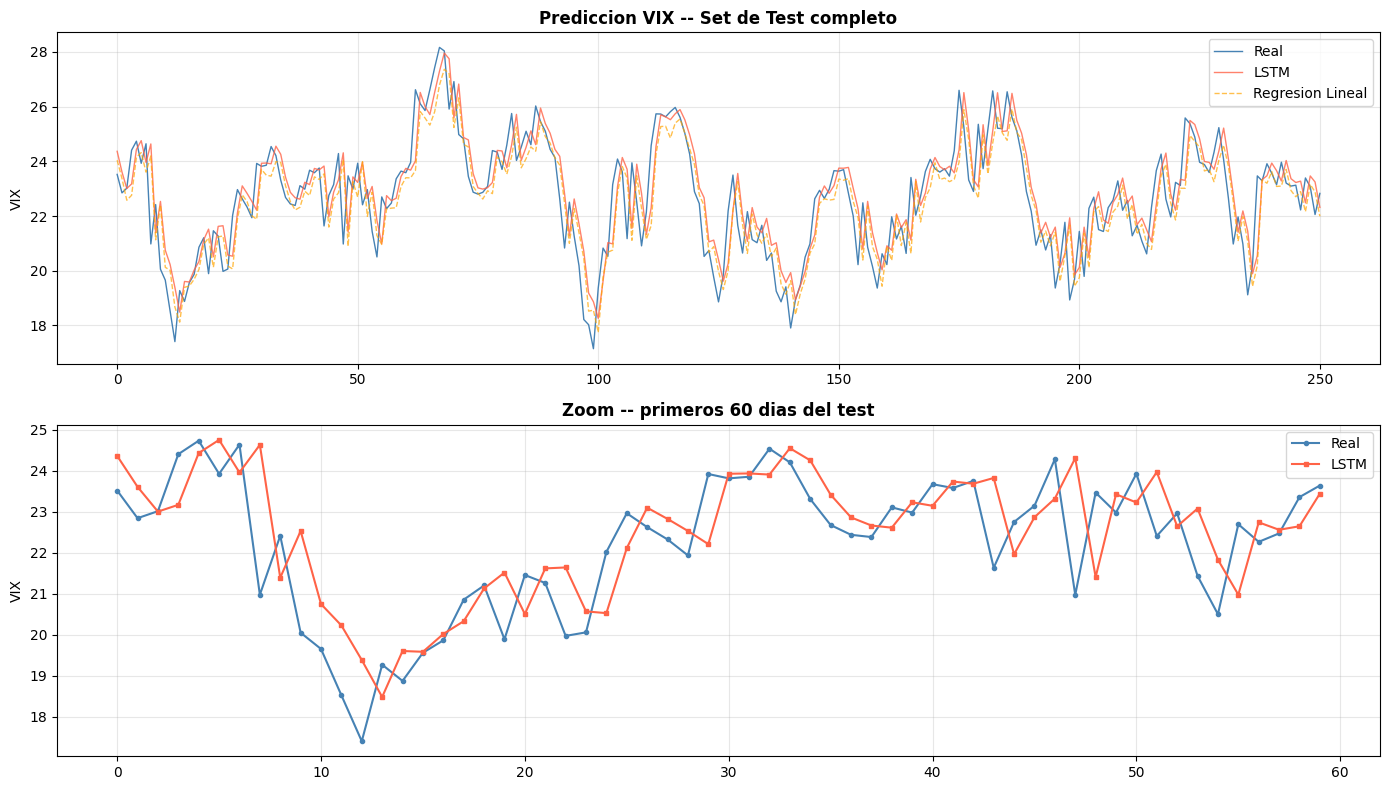

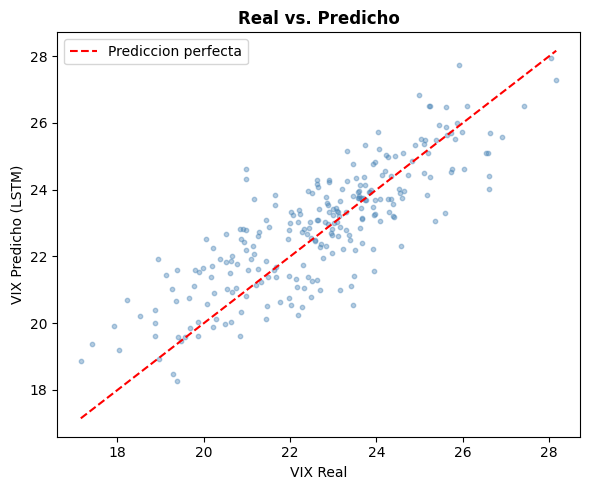

In [12]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# Serie completa: real vs. predicciones
axes[0].plot(y_real, label='Real', color='steelblue', linewidth=1)
axes[0].plot(y_pred_lstm, label='LSTM', color='tomato', linewidth=1, alpha=0.8)
axes[0].plot(y_pred_lr, label='Regresion Lineal', color='orange', linewidth=1, alpha=0.7, linestyle='--')
axes[0].set_title('Prediccion VIX -- Set de Test completo', fontweight='bold')
axes[0].legend()
axes[0].set_ylabel('VIX')
axes[0].grid(alpha=0.3)

# Zoom a los primeros 60 dias, para ver el detalle dia a dia
zoom = 60
axes[1].plot(y_real[:zoom], label='Real', color='steelblue', linewidth=1.5, marker='o', markersize=3)
axes[1].plot(y_pred_lstm[:zoom], label='LSTM', color='tomato', linewidth=1.5, marker='s', markersize=3)
axes[1].set_title(f'Zoom -- primeros {zoom} dias del test', fontweight='bold')
axes[1].legend()
axes[1].set_ylabel('VIX')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Scatter: prediccion perfecta seria la diagonal
plt.figure(figsize=(6, 5))
plt.scatter(y_real, y_pred_lstm, alpha=0.4, color='steelblue', s=10)
lims = [min(y_real.min(), y_pred_lstm.min()), max(y_real.max(), y_pred_lstm.max())]
plt.plot(lims, lims, 'r--', label='Prediccion perfecta')
plt.xlabel('VIX Real')
plt.ylabel('VIX Predicho (LSTM)')
plt.title('Real vs. Predicho', fontweight='bold')
plt.legend()
plt.tight_layout()
plt.show()

**Cómo leer estos 3 gráficos:**

- **Serie completa (arriba):** la curva de la LSTM debería seguir la tendencia general de la real, pero
  probablemente "suavizada" — no llega a los picos más agudos. Esto es típico de un modelo entrenado
  para minimizar el error cuadrático medio (`MSE`): terminan prefiriendo estar "cerca en promedio" antes
  que arriesgarse a predicciones extremas.
- **Zoom (abajo):** acá se ve mejor el detalle día a día — cuanto más cerca estén los puntos rojos de
  los azules, mejor.
- **Scatter (real vs. predicho):** si el modelo fuera perfecto, todos los puntos caerían sobre la línea
  roja punteada. Una nube de puntos alineada y simétrica alrededor de la diagonal (sin inclinarse
  sistemáticamente hacia arriba o abajo) indica que el modelo **no tiene sesgo** — no sobreestima ni
  subestima de forma consistente.


## 9. Conclusiones

### ¿Es el VIX predecible, o se comporta como un random walk?

Un **random walk puro** implicaría que cada cambio es 100% aleatorio: $VIX(t) = VIX(t-1) + \varepsilon$,
con $\varepsilon$ puro ruido. Si ese fuera el caso, la autocorrelación de la Sección 3 sería
prácticamente cero para todos los lags, y **ningún modelo** (ni la persistencia) podría superar a
adivinar al azar.

Lo que encontramos (ejemplo de una corrida típica de este notebook):

| Modelo | MAE | RMSE | R² |
|---|---|---|---|
| 🧠 LSTM | ~0.93 | ~1.18 | **~+0.67** |
| 📈 Regresión Lineal | ~0.93 | ~1.18 | ~+0.67 |
| 📌 Persistencia | ~0.97 | ~1.21 | ~+0.66 |

*(Los números exactos de esta corrida están arriba, en la Sección 8 — esta tabla es una guía de
referencia, no reemplaza el resultado real que obtuvieron.)*

Un R² de ~0.67 significa que el modelo explica **el 67% de la varianza** del VIX en el set de test.
Eso está lejos de 0 (donde estaría un random walk puro) → **el VIX simulado tiene estructura temporal
real y aprovechable.**

### El hallazgo más interesante de esta clase: LSTM ≈ Regresión Lineal

Si sus números también salieron así de parecidos entre LSTM y Regresión Lineal, **no es un error ni una
mala noticia** — es información valiosa: significa que la parte "predecible" de esta serie es
predominantemente **lineal**. Una LSTM, con toda su capacidad de capturar relaciones no lineales
complejas, no encuentra nada extra que aprovechar aquí. Esto suele pasar cuando:

- La serie está dominada por autocorrelación de corto plazo ("hoy ≈ ayer").
- No hay patrones no lineales fuertes en la ventana de tiempo analizada.
- El dataset es una versión **simulada y suavizada** del VIX real, sin los eventos extremos (crisis,
  pánicos) donde sí suelen aparecer relaciones no lineales.

**La lección para llevarse:** más complejidad (más parámetros, arquitecturas más sofisticadas) no
siempre significa mejor resultado. Comparar contra un baseline simple es lo que nos permite darnos
cuenta de esto — sin la Sección 8, hubiéramos podido creer erróneamente que "la LSTM predice muy bien"
sin notar que un modelo mucho más simple hace exactamente lo mismo.

### Limitaciones a tener en cuenta
- El VIX real tuvo picos mucho más extremos (ej. ~85 en la pandemia de COVID, ~80 en la crisis
  financiera de 2008) que este dataset simulado no reproduce. En una serie real con esos regímenes de
  alta volatilidad, es más probable que una LSTM sí supere a un modelo lineal.
- Con ~1.300 filas de datos y ~50.000 parámetros, la LSTM está en un terreno delicado: podría estar
  sub-entrenada, o el problema simplemente no requiere tanta capacidad.
- No se usó *early stopping* ni regularización avanzada — quedan como posibles próximos pasos
  (ver la consigna de *extra credit* de la clase).

### Para la próxima vez que expliquen esto
Si alguien pregunta "¿entonces para qué sirvió entrenar la LSTM?", la respuesta honesta y didáctica es:
**sirvió para descubrir, comparando contra baselines, que en este dataset la señal es lineal.** Ese es
un resultado tan válido y útil como "la LSTM ganó por mucho" — el objetivo de un buen análisis nunca es
que el modelo más complejo gane, sino **entender la naturaleza de los datos**.


## 10. Glosario exprés

Para repasar rápido antes de explicar la clase:

- **VIX**: índice de volatilidad esperada del S&P 500 ("índice del miedo").
- **Serie temporal**: datos ordenados en el tiempo, donde el orden importa.
- **Autocorrelación**: cuánto se parece un valor de la serie a valores anteriores (lags).
- **Random walk**: proceso donde cada paso es aleatorio e impredecible a partir del pasado.
- **LSTM**: red neuronal recurrente con "puertas" (forget/input/output) que decide qué recordar y qué
  olvidar a lo largo de una secuencia.
- **Lookback / ventana deslizante**: cuántos pasos de tiempo hacia atrás mira el modelo para predecir el
  siguiente.
- **MinMaxScaler / normalización**: llevar los datos a un rango fijo (ej. [0,1]) para que la red entrene
  mejor.
- **Data leakage**: cuando información del futuro (o del set de test) se filtra al entrenamiento,
  inflando artificialmente el rendimiento del modelo.
- **Tensor**: la estructura de datos de PyTorch (similar a un array de NumPy) sobre la que se calculan
  gradientes y se corre en GPU.
- **batch_first / (batch, seq_len, features)**: la forma en que PyTorch espera los datos de entrada para
  una LSTM.
- **Forward pass**: el camino de los datos desde la entrada hasta la predicción.
- **Función de pérdida (loss)**: mide qué tan lejos está la predicción del valor real (acá, `MSE`).
- **Backpropagation / backward pass**: el cálculo de gradientes que le dice a cada peso "hacia dónde
  moverse" para reducir el error.
- **Optimizador (Adam)**: la regla que usa esos gradientes para efectivamente actualizar los pesos.
- **Época (epoch)**: una pasada completa por todos los datos de entrenamiento.
- **Batch**: un subconjunto de ejemplos que se procesa junto en cada paso de entrenamiento.
- **Dropout**: apagar neuronas al azar durante el entrenamiento, para evitar sobreajuste.
- **Overfitting (sobreajuste)**: cuando el modelo "memoriza" el train set en vez de aprender un patrón
  general, y por eso rinde peor en datos nuevos.
- **TimeSeriesSplit**: validación cruzada que respeta el orden temporal (nunca valida con datos
  anteriores al train de ese fold).
- **Baseline (modelo base)**: un modelo simple de referencia (ej. persistencia, regresión lineal) contra
  el que siempre hay que comparar un modelo más complejo.
- **MAE / RMSE / R²**: métricas para medir qué tan buenas son las predicciones (ver Sección 8 para el
  detalle de cada una).
